## Importing Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, silhouette_score

import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [31]:
df = pd.read_csv(r'Space_Industry_Analytics_2010_2024.csv')
df

,Company,Year,Launches,Successful,Failed,Revenue_USD_M,Budget_Funding_USD_M,Employees,Rockets,Success_Rate_%
0,SpaceX,2010,2,2,0,80,150,1100,1,100.00
1,SpaceX,2011,0,0,0,180,200,1800,1,0.00
2,SpaceX,2012,2,2,0,300,400,2500,1,100.00
3,SpaceX,2013,3,3,0,500,500,3000,2,100.00
4,SpaceX,2014,6,6,0,1000,600,4000,2,100.00
5,SpaceX,2015,7,6,1,1300,1000,5000,2,85.71
6,SpaceX,2016,9,8,1,1600,1200,6000,2,88.89
7,SpaceX,2017,18,18,0,2200,1500,7000,3,100.00
8,SpaceX,2018,21,21,0,2900,2000,8000,3,100.00
9,SpaceX,2019,13,13,0,1450,2500,9000,3,100.00


## EDA

In [32]:
df.head

<bound method NDFrame.head of        Company  Year  Launches  Successful  Failed  Revenue_USD_M  \
0       SpaceX  2010         2           2       0             80   
1       SpaceX  2011         0           0       0            180   
2       SpaceX  2012         2           2       0            300   
3       SpaceX  2013         3           3       0            500   
4       SpaceX  2014         6           6       0           1000   
5       SpaceX  2015         7           6       1           1300   
6       SpaceX  2016         9           8       1           1600   
7       SpaceX  2017        18          18       0           2200   
8       SpaceX  2018        21          21       0           2900   
9       SpaceX  2019        13          13       0           1450   
10      SpaceX  2020        27          27       0           2500   
11      SpaceX  2021        33          33       0           4200   
12      SpaceX  2022        61          61       0           6000   
13  

In [33]:
df.shape

(45, 10)

In [34]:
df.info

<bound method DataFrame.info of        Company  Year  Launches  Successful  Failed  Revenue_USD_M  \
0       SpaceX  2010         2           2       0             80   
1       SpaceX  2011         0           0       0            180   
2       SpaceX  2012         2           2       0            300   
3       SpaceX  2013         3           3       0            500   
4       SpaceX  2014         6           6       0           1000   
5       SpaceX  2015         7           6       1           1300   
6       SpaceX  2016         9           8       1           1600   
7       SpaceX  2017        18          18       0           2200   
8       SpaceX  2018        21          21       0           2900   
9       SpaceX  2019        13          13       0           1450   
10      SpaceX  2020        27          27       0           2500   
11      SpaceX  2021        33          33       0           4200   
12      SpaceX  2022        61          61       0           6000   
13

In [35]:
df.describe()

,Year,Launches,Successful,Failed,Revenue_USD_M,Budget_Funding_USD_M,Employees,Rockets,Success_Rate_%
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,2017.000000,13.288889,13.200000,0.088889,1046.288889,7768.222222,8768.955556,2.111111,78.694889
std,4.369314,25.074092,25.105776,0.287799,2519.076857,9417.102189,7835.731778,1.265310,40.173679
min,2010.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5.000000,0.000000,0.000000
25%,2013.000000,3.000000,2.000000,0.000000,0.000000,150.000000,900.000000,1.000000,88.890000
50%,2017.000000,7.000000,6.000000,0.000000,1.000000,1800.000000,7000.000000,2.000000,100.000000
75%,2021.000000,10.000000,10.000000,0.000000,500.000000,18010.000000,17500.000000,3.000000,100.000000
max,2024.000000,134.000000,134.000000,1.000000,13100.000000,25400.000000,19000.000000,5.000000,100.000000


In [36]:
df.isnull().sum()

Company                 0
Year                    0
Launches                0
Successful              0
Failed                  0
Revenue_USD_M           0
Budget_Funding_USD_M    0
Employees               0
Rockets                 0
Success_Rate_%          0
dtype: int64

## Data Cleaning 

In [37]:
df_clean = df.copy()
df_clean["Company"] = df_clean["Company"].astype("category")
print("After cleaning records:", len(df_clean))

After cleaning records: 45


## Company-wise Launches Overview

In [38]:
company_launches = df_clean.groupby('Company')['Launches'].sum().sort_values(ascending=False)
company_launches

Company
SpaceX        434
NASA          106
Rocket Lab     58
Name: Launches, dtype: int64

## Average Success Rate by Company

In [39]:
avg_success = df_clean.groupby('Company')['Success_Rate_%'].mean().sort_values(ascending=False)
avg_success

Company
NASA          100.000000
SpaceX         91.640000
Rocket Lab     44.444667
Name: Success_Rate_%, dtype: float64

## Revenue vs Budget Visualization

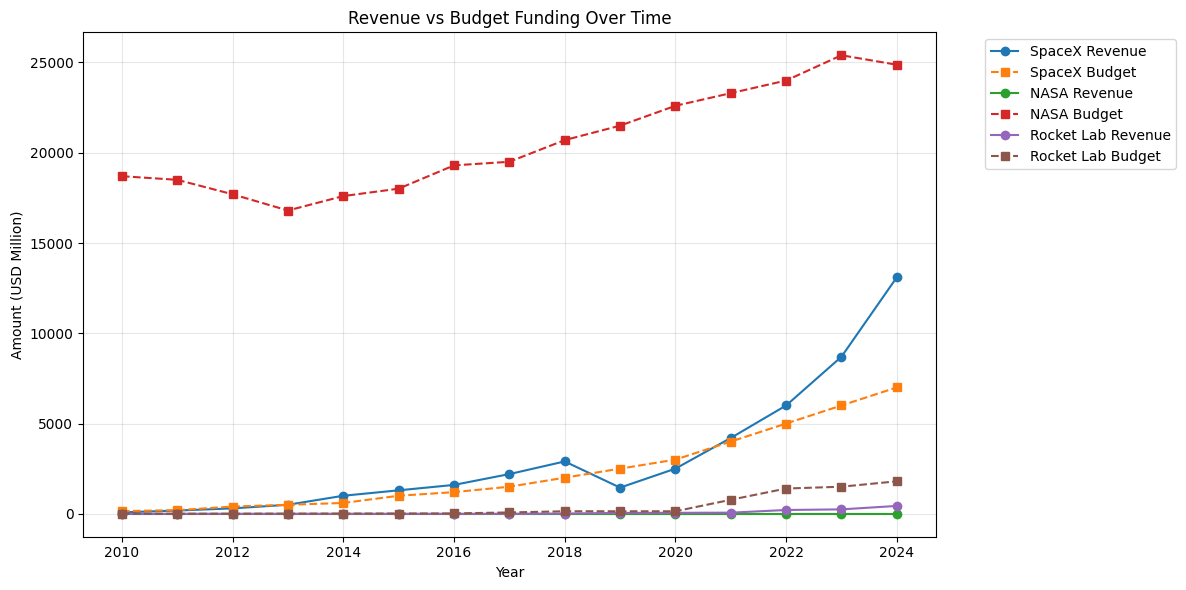

In [40]:
plt.figure(figsize=(12, 6))
for company in df_clean['Company'].unique():
    company_data = df_clean[df_clean['Company'] == company]
    plt.plot(company_data['Year'], company_data['Revenue_USD_M'], marker='o', label=f'{company} Revenue')
    plt.plot(company_data['Year'], company_data['Budget_Funding_USD_M'], marker='s', linestyle='--', label=f'{company} Budget')

plt.xlabel('Year')
plt.ylabel('Amount (USD Million)')
plt.title('Revenue vs Budget Funding Over Time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Launches Over Time by Company

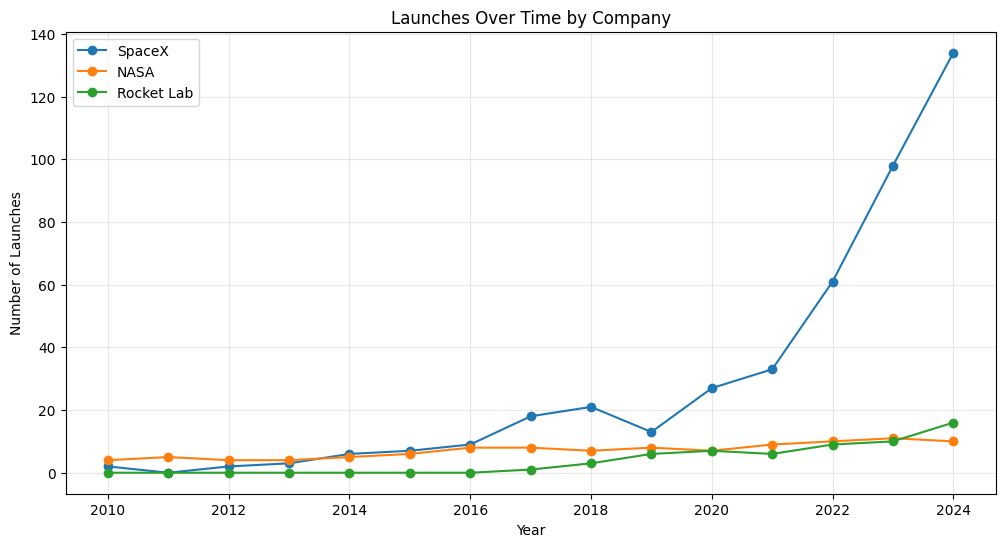

In [41]:
plt.figure(figsize=(12, 6))
for company in df_clean['Company'].unique():
    company_data = df_clean[df_clean['Company'] == company]
    plt.plot(company_data['Year'], company_data['Launches'], marker='o', label=company)

plt.xlabel('Year')
plt.ylabel('Number of Launches')
plt.title('Launches Over Time by Company')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Data Preparation for ML

In [42]:
le = LabelEncoder()
df_ml = df_clean.copy()
df_ml['Company_Encoded'] = le.fit_transform(df_ml['Company'])
features = ['Year', 'Company_Encoded', 'Budget_Funding_USD_M', 'Employees', 'Rockets']
target_reg = 'Revenue_USD_M'  # Regression target
target_class = 'Success_Rate_%'  # Classification target

X = df_ml[features]
y_reg = df_ml[target_reg]
y_class = (df_ml[target_class] >= 100).astype(int)  # Binary classification: 100% success or not
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_class, y_test_class = train_test_split(X, y_class, test_size=0.2, random_state=42)

print("Regression - Training set:", X_train.shape, "Test set:", X_test.shape)
print("Classification - Training set:", X_train_c.shape, "Test set:", X_test_c.shape)

Regression - Training set: (36, 5) Test set: (9, 5)
Classification - Training set: (36, 5) Test set: (9, 5)


## Feature Scaling

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

## Linear Regression - Revenue Prediction

In [44]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_reg)
y_pred_lr = lr.predict(X_test_scaled)
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)
print("LINEAR REGRESSION - Revenue Prediction")
print(f"Mean Squared Error: {mse_lr:.2f}")
print(f"Root Mean Squared Error: {rmse_lr:.2f}")
print(f"R² Score: {r2_lr:.4f}")
print("\nFeature Coefficients:")
for feature, coef in zip(features, lr.coef_):
    print(f"{feature}: {coef:.2f}")

LINEAR REGRESSION - Revenue Prediction
Mean Squared Error: 254686.38
Root Mean Squared Error: 504.66
R² Score: 0.9322

Feature Coefficients:
Year: 482.11
Company_Encoded: -512.10
Budget_Funding_USD_M: -5194.60
Employees: 4419.16
Rockets: 625.66


## Random Forest Regression

In [45]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_scaled, y_train_reg)
y_pred_rf = rf_reg.predict(X_test_scaled)
mse_rf = mean_squared_error(y_test_reg, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test_reg, y_pred_rf)

print("RANDOM FOREST REGRESSION - Revenue Prediction")
print(f"Mean Squared Error: {mse_rf:.2f}")
print(f"Root Mean Squared Error: {rmse_rf:.2f}")
print(f"R² Score: {r2_rf:.4f}")
print("\nFeature Importance:")
for feature, importance in zip(features, rf_reg.feature_importances_):
    print(f"{feature}: {importance:.4f}")

RANDOM FOREST REGRESSION - Revenue Prediction
Mean Squared Error: 748389.56
Root Mean Squared Error: 865.10
R² Score: 0.8007

Feature Importance:
Year: 0.0831
Company_Encoded: 0.1325
Budget_Funding_USD_M: 0.0387
Employees: 0.0586
Rockets: 0.6871


## Gradient Boosting Regression

In [46]:
gb_reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_reg.fit(X_train_scaled, y_train_reg)
y_pred_gb = gb_reg.predict(X_test_scaled)
mse_gb = mean_squared_error(y_test_reg, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test_reg, y_pred_gb)

print("GRADIENT BOOSTING REGRESSION - Revenue Prediction")
print(f"Mean Squared Error: {mse_gb:.2f}")
print(f"Root Mean Squared Error: {rmse_gb:.2f}")
print(f"R² Score: {r2_gb:.4f}")

GRADIENT BOOSTING REGRESSION - Revenue Prediction
Mean Squared Error: 548406.73
Root Mean Squared Error: 740.54
R² Score: 0.8539


## Logistic Regression - Success Rate Classification

In [47]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_c_scaled, y_train_class)
y_pred_log = log_reg.predict(X_test_c_scaled)
print("LOGISTIC REGRESSION - Success Rate Classification")
print(f"Accuracy: {accuracy_score(y_test_class, y_pred_log):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_log, target_names=['<100%', '100%']))

LOGISTIC REGRESSION - Success Rate Classification
Accuracy: 0.8889

Classification Report:
              precision    recall  f1-score   support

       <100%       0.50      1.00      0.67         1
        100%       1.00      0.88      0.93         8

    accuracy                           0.89         9
   macro avg       0.75      0.94      0.80         9
weighted avg       0.94      0.89      0.90         9



## Decision Tree Classification

In [48]:
dt_class = DecisionTreeClassifier(random_state=42)
dt_class.fit(X_train_c_scaled, y_train_class)
y_pred_dt = dt_class.predict(X_test_c_scaled)
print("DECISION TREE CLASSIFICATION - Success Rate Classification")
print(f"Accuracy: {accuracy_score(y_test_class, y_pred_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_dt, target_names=['<100%', '100%']))
print("\nFeature Importance:")
for feature, importance in zip(features, dt_class.feature_importances_):
    print(f"{feature}: {importance:.4f}")

DECISION TREE CLASSIFICATION - Success Rate Classification
Accuracy: 0.8889

Classification Report:
              precision    recall  f1-score   support

       <100%       0.50      1.00      0.67         1
        100%       1.00      0.88      0.93         8

    accuracy                           0.89         9
   macro avg       0.75      0.94      0.80         9
weighted avg       0.94      0.89      0.90         9


Feature Importance:
Year: 0.1047
Company_Encoded: 0.0000
Budget_Funding_USD_M: 0.2459
Employees: 0.6494
Rockets: 0.0000


## Random Forest Classification

In [49]:
rf_class = RandomForestClassifier(n_estimators=100, random_state=42)
rf_class.fit(X_train_c_scaled, y_train_class)
y_pred_rf_class = rf_class.predict(X_test_c_scaled)
print("RANDOM FOREST CLASSIFICATION - Success Rate Classification")
print(f"Accuracy: {accuracy_score(y_test_class, y_pred_rf_class):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_rf_class, target_names=['<100%', '100%']))
print("\nFeature Importance:")
for feature, importance in zip(features, rf_class.feature_importances_):
    print(f"{feature}: {importance:.4f}")

RANDOM FOREST CLASSIFICATION - Success Rate Classification
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

       <100%       1.00      1.00      1.00         1
        100%       1.00      1.00      1.00         8

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9


Feature Importance:
Year: 0.1072
Company_Encoded: 0.0449
Budget_Funding_USD_M: 0.3519
Employees: 0.3740
Rockets: 0.1220


## K-Means Clustering


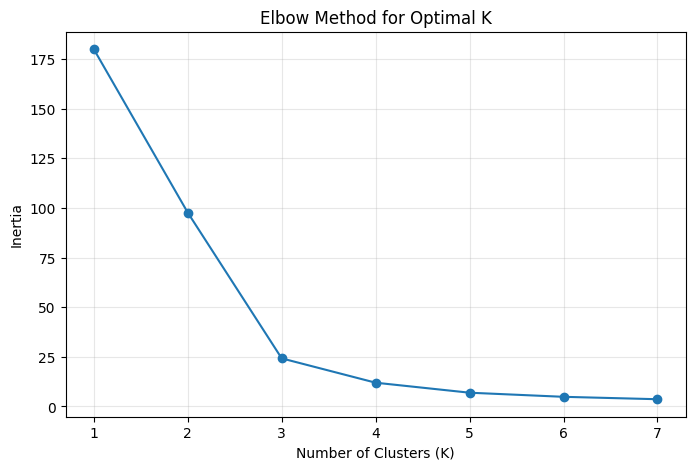

K-MEANS CLUSTERING - Company Years Grouped

Cluster Distribution:
Cluster
1    27
0    15
2     3
Name: count, dtype: int64

Cluster Centers (Scaled):
   Launches   Revenue    Budget  Employees
0 -0.250958 -0.420039  1.374314   1.178476
1 -0.238708 -0.133325 -0.742409  -0.763184
2  3.403163  3.300124 -0.189889   0.976278

Silhouette Score: 0.7533


In [50]:
X_cluster = df_ml[['Launches', 'Revenue_USD_M', 'Budget_Funding_USD_M', 'Employees']]
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)
inertias = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 8), inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True, alpha=0.3)
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ml['Cluster'] = kmeans.fit_predict(X_cluster_scaled)
print("K-MEANS CLUSTERING - Company Years Grouped")
print("\nCluster Distribution:")
print(df_ml['Cluster'].value_counts())
print("\nCluster Centers (Scaled):")
print(pd.DataFrame(kmeans.cluster_centers_, columns=['Launches', 'Revenue', 'Budget', 'Employees']))

sil_score = silhouette_score(X_cluster_scaled, df_ml['Cluster'])
print(f"\nSilhouette Score: {sil_score:.4f}")

## Cluster Visualization

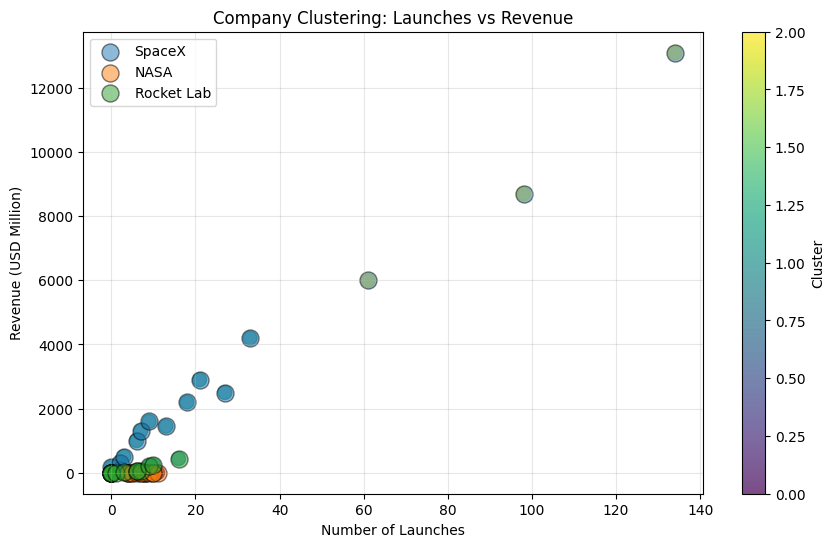

In [51]:
# Visualize Clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_ml['Launches'], df_ml['Revenue_USD_M'], 
                     c=df_ml['Cluster'], cmap='viridis', s=100, alpha=0.7)

for company in df_ml['Company'].unique():
    company_data = df_ml[df_ml['Company'] == company]
    plt.scatter(company_data['Launches'], company_data['Revenue_USD_M'], 
               label=company, s=150, alpha=0.5, edgecolors='black', linewidth=1)

plt.xlabel('Number of Launches')
plt.ylabel('Revenue (USD Million)')
plt.title('Company Clustering: Launches vs Revenue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Cluster')
plt.show()

## Ensemble Learning - Model Comparison

In [52]:
from sklearn.ensemble import VotingRegressor, AdaBoostRegressor
ensemble_reg = VotingRegressor([
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=50, random_state=42))
])
ensemble_reg.fit(X_train_scaled, y_train_reg)
y_pred_ensemble = ensemble_reg.predict(X_test_scaled)

mse_ens = mean_squared_error(y_test_reg, y_pred_ensemble)
rmse_ens = np.sqrt(mse_ens)
r2_ens = r2_score(y_test_reg, y_pred_ensemble)
print("ENSEMBLE LEARNING - Voting Regressor Comparison")
print(f"Mean Squared Error: {mse_ens:.2f}")
print(f"Root Mean Squared Error: {rmse_ens:.2f}")
print(f"R² Score: {r2_ens:.4f}")

print("MODEL COMPARISON - R² SCORES")
print(f"Linear Regression: {r2_lr:.4f}")
print(f"Random Forest: {r2_rf:.4f}")
print(f"Gradient Boosting: {r2_gb:.4f}")
print(f"Ensemble (Voting): {r2_ens:.4f}")

ENSEMBLE LEARNING - Voting Regressor Comparison
Mean Squared Error: 225884.12
Root Mean Squared Error: 475.27
R² Score: 0.9398
MODEL COMPARISON - R² SCORES
Linear Regression: 0.9322
Random Forest: 0.8007
Gradient Boosting: 0.8539
Ensemble (Voting): 0.9398


## Future Year Prediction - Revenue Forecast

In [53]:
future_years = pd.DataFrame({
    'Year': [2025, 2026, 2027],
    'Company_Encoded': [le.transform(['SpaceX'])[0], le.transform(['SpaceX'])[0], le.transform(['SpaceX'])[0]],
    'Budget_Funding_USD_M': [7500, 8000, 8500],
    'Employees': [20000, 21000, 22000],
    'Rockets': [6, 6, 7]
})
future_scaled = scaler.transform(future_years)
future_revenue = ensemble_reg.predict(future_scaled)
print("REVENUE FORECAST (SpaceX)")
for year, revenue in zip([2025, 2026, 2027], future_revenue):
    print(f"{year}: ${revenue:,.0f} Million")

REVENUE FORECAST (SpaceX)
2025: $11,105 Million
2026: $11,237 Million
2027: $11,530 Million


## Company Performance Dashboard

In [54]:
summary_df = df_clean.groupby('Company').agg({
    'Launches': 'sum',
    'Successful': 'sum',
    'Failed': 'sum',
    'Revenue_USD_M': 'sum',
    'Employees': 'max',
    'Rockets': 'max',
    'Success_Rate_%': 'mean'
}).round(2)

summary_df.columns = ['Total Launches', 'Total Successful', 'Total Failed', 
                      'Total Revenue (M)', 'Max Employees', 'Max Rockets', 'Avg Success Rate']
summary_df['Success Rate'] = (summary_df['Total Successful'] / summary_df['Total Launches'] * 100).round(2)
print("SPACE INDUSTRY ANALYTICS - COMPANY PERFORMANCE DASHBOARD")
print(summary_df)

best_company = summary_df['Total Revenue (M)'].idxmax()
best_revenue = summary_df.loc[best_company, 'Total Revenue (M)']
print(f"\nTop Revenue Generator: {best_company} (${best_revenue:,.0f} Million)")
best_success = summary_df['Avg Success Rate'].idxmax()
best_success_rate = summary_df.loc[best_success, 'Avg Success Rate']
print(f"Best Success Rate: {best_success} ({best_success_rate:.1f}%)")

SPACE INDUSTRY ANALYTICS - COMPANY PERFORMANCE DASHBOARD
            Total Launches  Total Successful  Total Failed  Total Revenue (M)  \
Company                                                                         
NASA                   106               106             0                  0   
Rocket Lab              58                56             2               1073   
SpaceX                 434               432             2              46010   

            Max Employees  Max Rockets  Avg Success Rate  Success Rate  
Company                                                                 
NASA                19000            4            100.00        100.00  
Rocket Lab           2100            2             44.44         96.55  
SpaceX              19000            5             91.64         99.54  

Top Revenue Generator: SpaceX ($46,010 Million)
Best Success Rate: NASA (100.0%)


## Success Rate Trend by Company

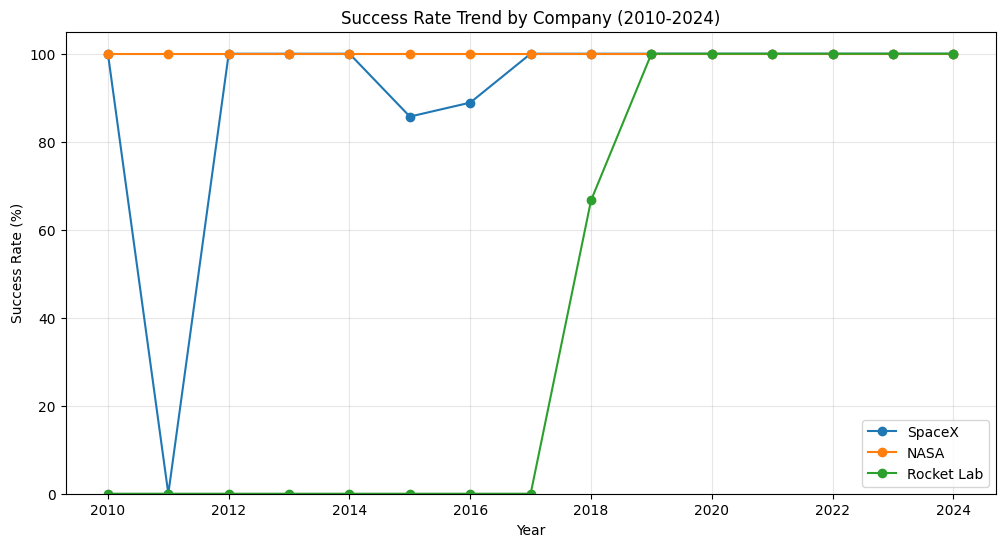

In [55]:
plt.figure(figsize=(12, 6))
for company in df_clean['Company'].unique():
    company_data = df_clean[df_clean['Company'] == company]
    plt.plot(company_data['Year'], company_data['Success_Rate_%'], marker='o', label=company)

plt.xlabel('Year')
plt.ylabel('Success Rate (%)')
plt.title('Success Rate Trend by Company (2010-2024)')
plt.ylim(0, 105)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Revenue vs Employees Relationship

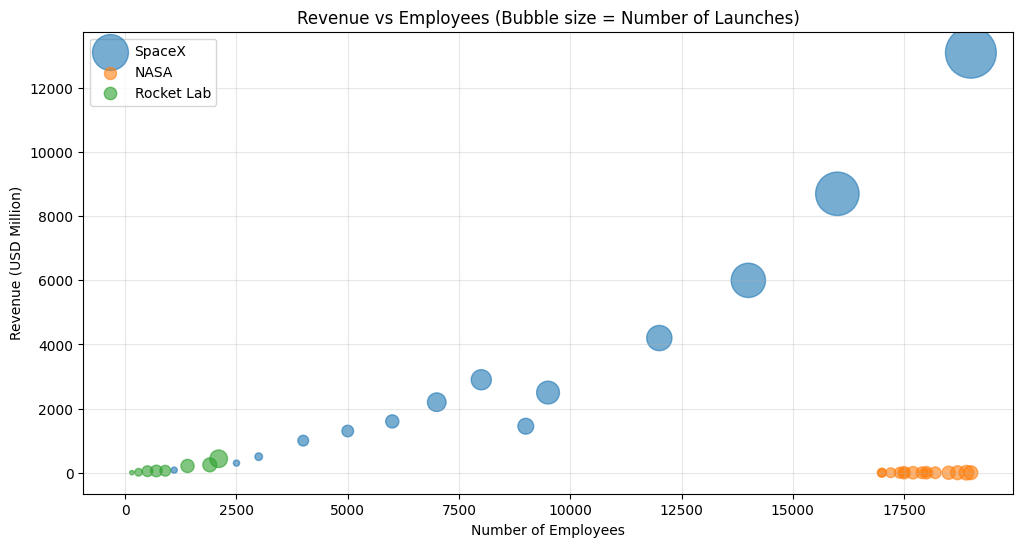

In [56]:
plt.figure(figsize=(12, 6))
for company in df_clean['Company'].unique():
    company_data = df_clean[df_clean['Company'] == company]
    plt.scatter(company_data['Employees'], company_data['Revenue_USD_M'], 
               label=company, s=company_data['Launches']*10, alpha=0.6)

plt.xlabel('Number of Employees')
plt.ylabel('Revenue (USD Million)')
plt.title('Revenue vs Employees (Bubble size = Number of Launches)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()